# LSTM


## 简介
Long Short-Term Memory (LSTM) 通过记忆单元来保留长期依赖信息，并使用输入门、遗忘门和输出门来控制信息的流动。
- 输入门：控制当前输入信息的多少被写入记忆单元。
- 遗忘门：控制记忆单元中信息的保留和遗忘
- 输出门：控制记忆单元中信息的多少被输出到下一层。

## 门
输出 $(0, 1)$ 之间的值，控制信息的流动。

![LSTM](./images/lstm-gate.svg)

$$F_t = \sigma(W_{xf}x_t + W_{hf}h_{t-1} + b_f)$$
$$I_t = \sigma(W_{xi}x_t + W_{hi}h_{t-1} + b_i)$$
$$O_t = \sigma(W_{xo}x_t + W_{ho}h_{t-1} + b_o)$$

## 候选记忆单元
同 RNN 隐藏状态计算公式，算出的是新记忆。

![candidate](images/lstm-candidate.svg)

$$\tilde{C_t} = \tanh(W_{xc}x_t + W_{hc}h_{t-1} + b_c)$$

## 记忆单元
根据遗忘门和输入门的调整，融合新记忆和老记忆。

![cell](images/lstm-cell.svg)

$$C_t = F_t \odot C_{t-1} + I_t \odot \tilde{C_t}$$

## 隐藏状态
输出门决定取记忆单元的多少作为隐藏状态，tanh 确保值在 $(-1, 1)$ 之间。

![hidden](images/lstm-hidden.svg)

$$H_t = O_t \odot \tanh(C_t)$$


## 从零实现


In [1]:
import torch
from torch import nn
import util

/root/autodl-tmp/envs/daily_learning/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
batch_size = 32
num_steps = 35
train_iter, vocab = util.data.load_data_time_machine(batch_size, num_steps)

初始化模型参数


In [3]:
def get_params(vocab_size, num_hiddens, device):
    def normal(shape):
        return torch.randn(size=shape, device=device) * 0.01
    def three():
        return (normal((vocab_size, num_hiddens)), # Wx
                normal((num_hiddens, num_hiddens)), # Wh
                torch.zeros(num_hiddens, device=device)) # b
    W_xi, W_hi, b_i = three()  # 输入门
    W_xf, W_hf, b_f = three()  # 遗忘门
    W_xo, W_ho, b_o = three()  # 输出门
    W_xc, W_hc, b_c = three()  # 候选记忆单元
    # 输出层参数
    W_hq = normal((num_hiddens, vocab_size))
    b_q = torch.zeros(vocab_size, device=device)
    # 附上梯度
    params = [W_xi, W_hi, b_i,
              W_xf, W_hf, b_f,
              W_xo, W_ho, b_o,
              W_xc, W_hc, b_c,
              W_hq, b_q]
    for param in params:
        param.requires_grad_(True)
    return params

初始化记忆单元和隐藏状态


In [4]:
def init_lstm_state(batch_size, num_hiddens, device):
    return (torch.zeros((batch_size, num_hiddens), device=device), # 记忆单元
            torch.zeros((batch_size, num_hiddens), device=device)) # 隐藏状态

前向计算


In [5]:
def lstm(inputs, state, params):
    # 参数
    (W_xi, W_hi, b_i,
     W_xf, W_hf, b_f,
     W_xo, W_ho, b_o,
     W_xc, W_hc, b_c,
     W_hq, b_q) = params
    # 状态
    (C, H) = state
    outputs = []
    for X in inputs:
        I = torch.sigmoid(X @ W_xi + H @ W_hi + b_i) # 输入门
        F = torch.sigmoid(X @ W_xf + H @ W_hf + b_f) # 遗忘门
        O = torch.sigmoid(X @ W_xo + H @ W_ho + b_o) # 输出门
        C_tilda = torch.tanh(X @ W_xc + H @ W_hc + b_c) # 候选记忆单元
        C = F * C + I * C_tilda # 记忆单元
        H = O * torch.tanh(C) # 隐藏状态
        Y = H @ W_hq + b_q # 输出层
        outputs.append(Y)
    return torch.cat(outputs, dim=0), (C, H)

训练


困惑度 2.8, 39865.2 token/秒
time traveller at last i was done see thesunge of the sunded i sa
traveller the same resuld of our own time and she was so fro


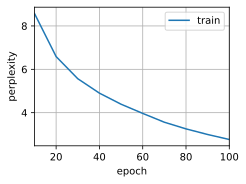

In [6]:
vocab_size = len(vocab)
num_hiddens = 256
device = util.try_gpu()
num_epochs = 100
lr = 1
model = util.model.RNNModelScratch(len(vocab), num_hiddens, device, get_params, init_lstm_state, lstm)
util.train.train_ch8(model, train_iter, vocab, lr, num_epochs, device)

## 简洁实现


困惑度 2.4, 534656.3 token/秒
time traveller still the problemsof of the laboratory in the same
traveller a mother me was all a minute the sunseed of the st


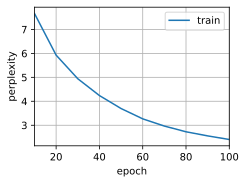

In [7]:
gru_layer = nn.LSTM(input_size=vocab_size, hidden_size=num_hiddens)
model = util.model.RNNModel(gru_layer, vocab_size).to(device)
util.train.train_ch8(model, train_iter, vocab, lr, num_epochs, device)